<a href="https://colab.research.google.com/github/Niranthveer/data-science-foundations/blob/main/internship_Level_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### LEVEL 3 - Task 1: Restaurant Reviews

In [ ]:
import pandas as pd

try:
    df = pd.read_csv('/content/Dataset .csv')
    print("Dataset loaded successfully. Displaying the first 5 rows and columns:")
    display(df.head())
    display(df.columns)
except FileNotFoundError:
    print("Error: 'Dataset .csv' not found. Please ensure the file is uploaded and the name is correct.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

review_column = 'Rating text'
rating_column = 'Aggregate rating'

print(f"Debug: review_column set to '{review_column}'")
print(f"Debug: rating_column set to '{rating_column}'")

if review_column in df.columns and rating_column in df.columns:
    df_reviews = df.dropna(subset=[review_column, rating_column]).copy()
    print("df_reviews created successfully.")
else:
    print(f"Error: Required columns '{review_column}' or '{rating_column}' not found in DataFrame for df_reviews creation.")
    print("Available columns:", df.columns.tolist())
    df_reviews = pd.DataFrame()

Dataset loaded successfully. Displaying the first 5 rows and columns:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Debug: review_column set to 'Rating text'
Debug: rating_column set to 'Aggregate rating'
df_reviews created successfully.


#### Task 1.1: Analyze the text reviews to identify the most common positive and negative keywords.

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

if not df_reviews.empty:
    df_reviews['processed_reviews'] = df_reviews[review_column].apply(preprocess_text)

    df_reviews[rating_column] = pd.to_numeric(df_reviews[rating_column], errors='coerce')
    df_reviews.dropna(subset=[rating_column], inplace=True)

    positive_reviews = df_reviews[df_reviews[rating_column] > 3]['processed_reviews']
    negative_reviews = df_reviews[df_reviews[rating_column] < 3]['processed_reviews']

    all_positive_words = [word for sublist in positive_reviews for word in sublist]
    all_negative_words = [word for sublist in negative_reviews for word in sublist]

    positive_word_counts = Counter(all_positive_words)
    print("\nMost common positive keywords:")
    for word, count in positive_word_counts.most_common(20):
        print(f"- {word}: {count}")

    negative_word_counts = Counter(all_negative_words)
    print("\nMost common negative keywords:")
    for word, count in negative_word_counts.most_common(20):
        print(f"- {word}: {count}")
else:
    print("df_reviews was not created. Skipping review processing.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Most common positive keywords:
- good: 3179
- average: 2022
- excellent: 301

Most common negative keywords:
- rated: 2148
- average: 1247
- poor: 186


#### Task 1.2: Calculate the average length of reviews and explore if there is a relationship between review length and rating.


Average review length: 1.34 words


/tmp/ipykernel_3995/1767826321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=rating_column, y='review_length', data=df_reviews, palette='viridis')


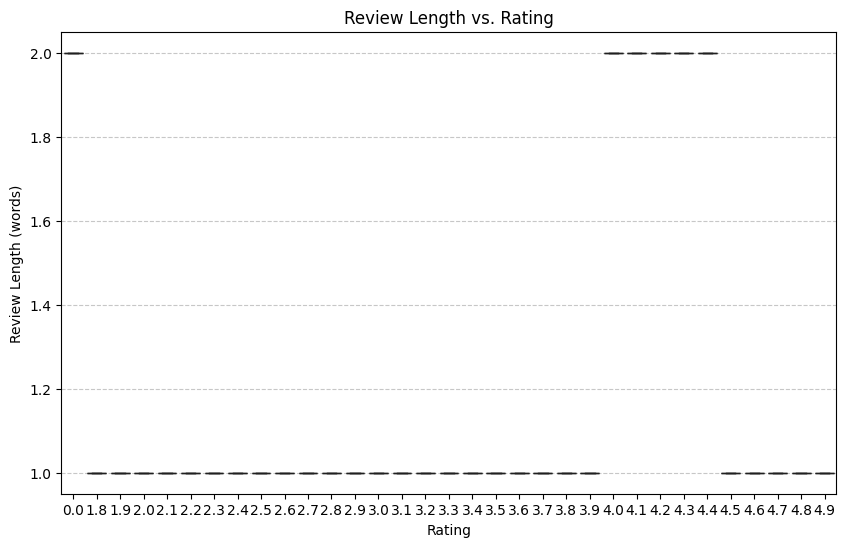


Average review length per rating:


,Aggregate rating,review_length
0,0.0,2.0
1,1.8,1.0
2,1.9,1.0
3,2.0,1.0
4,2.1,1.0
5,2.2,1.0
6,2.3,1.0
7,2.4,1.0
8,2.5,1.0
9,2.6,1.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df_reviews.empty:
    df_reviews['review_length'] = df_reviews[review_column].apply(lambda x: len(str(x).split()))

    average_review_length = df_reviews['review_length'].mean()
    print(f"\nAverage review length: {average_review_length:.2f} words")

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=rating_column, y='review_length', data=df_reviews, palette='viridis')
    plt.title('Review Length vs. Rating')
    plt.xlabel('Rating')
    plt.ylabel('Review Length (words)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    average_length_per_rating = df_reviews.groupby(rating_column)['review_length'].mean().reset_index()
    print("\nAverage review length per rating:")
    display(average_length_per_rating)
else:
    print("df_reviews was not created. Skipping review length analysis.")

### LEVEL 3 - Task 2: Votes Analysis

In [ ]:
restaurant_name_column = 'Restaurant Name'
votes_column = 'Votes'

print(f"Debug: restaurant_name_column set to '{restaurant_name_column}'")
print(f"Debug: votes_column set to '{votes_column}'")
print(f"Debug: rating_column used for df_votes creation is '{rating_column}'")

if restaurant_name_column not in df.columns or votes_column not in df.columns or rating_column not in df.columns:
    print(f"Warning: '{restaurant_name_column}', '{votes_column}', or '{rating_column}' column not found. Please check your dataset and adjust the column names if necessary.")
    print("Available columns:", df.columns.tolist())
    df_votes = pd.DataFrame()
else:
    df[votes_column] = pd.to_numeric(df[votes_column], errors='coerce')

    df_votes = df.dropna(subset=[restaurant_name_column, votes_column, rating_column]).copy()
    print("df_votes created successfully.")

Debug: restaurant_name_column set to 'Restaurant Name'
Debug: votes_column set to 'Votes'
Debug: rating_column used for df_votes creation is 'Aggregate rating'
df_votes created successfully.


#### Task 2.1: Identify the restaurants with the highest and lowest number of votes.

In [ ]:
if not df_votes.empty:
    restaurant_votes = df_votes.groupby(restaurant_name_column)[votes_column].sum().reset_index()

    highest_voted = restaurant_votes.sort_values(by=votes_column, ascending=False).head(10)
    print("\nTop 10 Restaurants with Highest Votes:")
    display(highest_voted)

    lowest_voted = restaurant_votes.sort_values(by=votes_column, ascending=True).head(10)
    print("\nTop 10 Restaurants with Lowest Votes:")
    display(lowest_voted)
else:
    print("df_votes was not created. Skipping votes analysis.")


Top 10 Restaurants with Highest Votes:


,Restaurant Name,Votes
663,Barbeque Nation,28142
101,AB's - Absolute Barbecues,13400
6943,Toit,10934
785,Big Chill,10853
2297,Farzi Cafe,10098
6988,Truffles,9682
1510,Chili's,8156
2879,Hauz Khas Social,7931
3261,Joey's Pizza,7807
4902,Peter Cat,7574



Top 10 Restaurants with Lowest Votes:


,Restaurant Name,Votes
960,Breaky2Dinner,0
989,Brown House Cafe,0
1001,Buddy 's. Pizza,0
1051,Buzybee,0
1041,Burj Al Arab,0
1070,Cafe #22hours,0
1078,Cafe 59,0
1135,Cafe Highway,0
1147,Cafe Lounge,0
1141,Cafe Krisa,0


#### Task 2.2: Analyze if there is a correlation between the number of votes and the rating of a restaurant.


Correlation between Number of Votes and Average Rating: 0.24


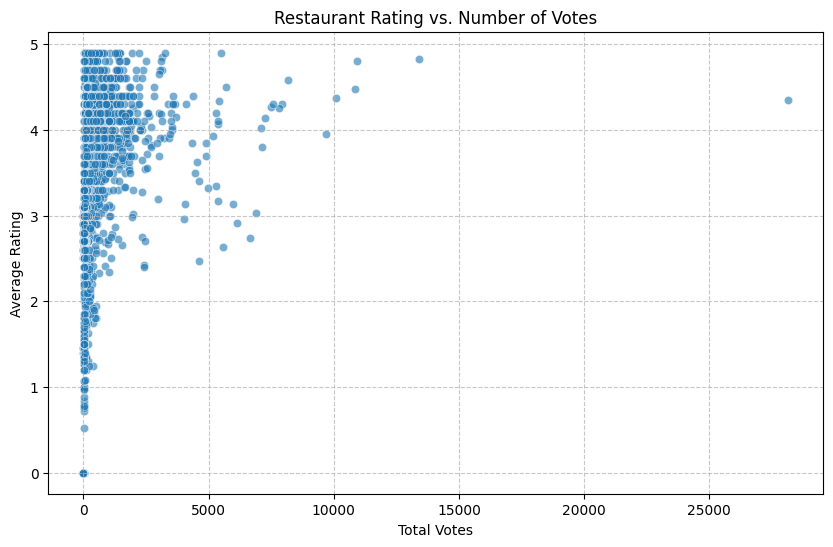

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df_votes.empty:
    restaurant_avg_rating = df_votes.groupby(restaurant_name_column)[rating_column].mean().reset_index()

    merged_data = pd.merge(restaurant_votes, restaurant_avg_rating, on=restaurant_name_column)

    correlation = merged_data[votes_column].corr(merged_data[rating_column])
    print(f"\nCorrelation between Number of Votes and Average Rating: {correlation:.2f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=votes_column, y=rating_column, data=merged_data, alpha=0.6)
    plt.title('Restaurant Rating vs. Number of Votes')
    plt.xlabel('Total Votes')
    plt.ylabel('Average Rating')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("df_votes was not created. Skipping correlation analysis.")

### LEVEL 3 - Task 3: Price Range vs. Online Delivery and Table Booking

In [ ]:
price_range_column = 'Price range'
online_delivery_column = 'Has Online delivery'
table_booking_column = 'Has Table booking'

print(f"Debug: price_range_column set to '{price_range_column}'")
print(f"Debug: online_delivery_column set to '{online_delivery_column}'")
print(f"Debug: table_booking_column set to '{table_booking_column}'")

if price_range_column not in df.columns or online_delivery_column not in df.columns or table_booking_column not in df.columns:
    print(f"Warning: '{price_range_column}', '{online_delivery_column}', or '{table_booking_column}' column not found. Please check your dataset and adjust the column names if necessary.")
    print("Available columns:", df.columns.tolist())
    df_services = pd.DataFrame()
else:
    df_services = df.dropna(subset=[price_range_column, online_delivery_column, table_booking_column]).copy()

    df_services[online_delivery_column] = df_services[online_delivery_column].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
    df_services[table_booking_column] = df_services[table_booking_column].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

    df_services[price_range_column] = df_services[price_range_column].astype('category')

    print("df_services created successfully.")

Debug: price_range_column set to 'Price range'
Debug: online_delivery_column set to 'Has Online delivery'
Debug: table_booking_column set to 'Has Table booking'
df_services created successfully.


#### Task 3.1: Analyze if there is a relationship between the price range and the availability of online delivery and table booking.


Proportion of restaurants offering services by Price Range:


/tmp/ipykernel_3995/634093256.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  services_by_price_range = df_services.groupby(price_range_column)[[


,Price range,Has Online delivery,Has Table booking
0,1,0.157741,0.000225
1,2,0.413106,0.076775
2,3,0.291903,0.457386
3,4,0.090444,0.467577


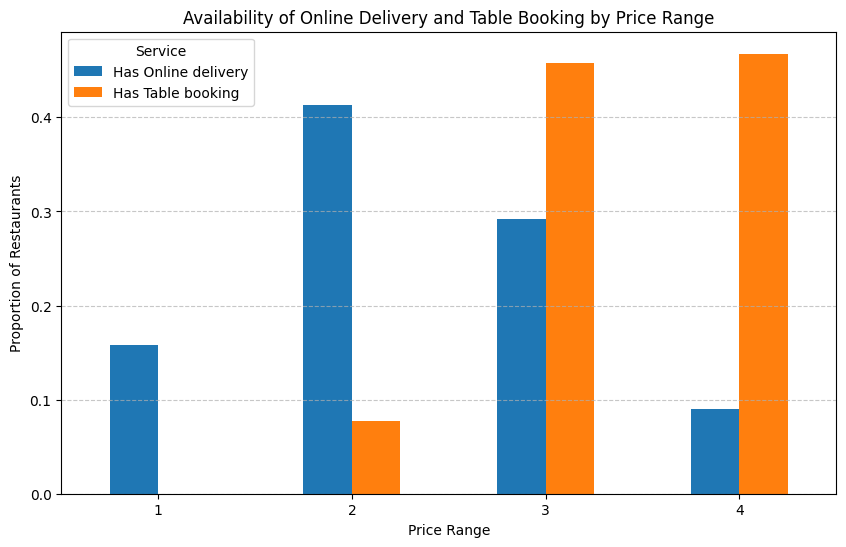

In [ ]:
import matplotlib.pyplot as plt

if not df_services.empty:
    services_by_price_range = df_services.groupby(price_range_column)[[
online_delivery_column, table_booking_column
    ]].mean().reset_index()

    print("\nProportion of restaurants offering services by Price Range:")
    display(services_by_price_range)

    services_by_price_range.set_index(price_range_column).plot(kind='bar', figsize=(10, 6))
    plt.title('Availability of Online Delivery and Table Booking by Price Range')
    plt.xlabel('Price Range')
    plt.ylabel('Proportion of Restaurants')
    plt.xticks(rotation=0)
    plt.legend(title='Service')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("df_services was not created. Skipping services analysis.")

#### Task 3.2: Determine if higher-priced restaurants are more likely to offer these services.

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
print("\nObservation based on the analysis:")
print("Review the 'Proportion of restaurants offering services by Price Range' table and the bar chart above.")
print("If the bars for 'Has Online delivery' and 'Has Table booking' tend to be taller for higher 'Price Range' values, then it indicates that higher-priced restaurants are more likely to offer these services.")


Observation based on the analysis:
Review the 'Proportion of restaurants offering services by Price Range' table and the bar chart above.
If the bars for 'Has Online delivery' and 'Has Table booking' tend to be taller for higher 'Price Range' values, then it indicates that higher-priced restaurants are more likely to offer these services.
